# Mask statistics
> Get mask statistics and pin count from images

In [ ]:
#| default_exp preprocessing.zero_degree_solder_pin.extract_pins

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2


In [ ]:
#| export
import sys
from pathlib import Path


In [ ]:
#| export
CV_TOOLS = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/cv_tools')
sys.path.append(str(CV_TOOLS))


In [ ]:
#| export
custom_lib_path = Path(r'/home/ai_warstein/homes/goni/custom_libs')
sys.path.append(str(custom_lib_path))


In [ ]:
#| export
from cv_tools.imports import *
from cv_tools.core import *
from dotenv import load_dotenv


In [ ]:
#| export
load_dotenv(dotenv_path=f'/home/ai_sintercra/homes/hasan/projects/git_data/new_test/new_test/.env')

In [ ]:
#| export
from concurrent.futures import ProcessPoolExecutor
from functools import partial
import cv2
import numpy as np
from tqdm import tqdm


In [ ]:
#| eval: false
from platform import system
if system() == 'Windows':
    core_path = Path(r'E:\CurrentTrainingData20240812_trn_val/trn_masks')
else:
    core_path = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/trn_masks')

MODEL_NAME='ETPD-WAR1_03.keras'
mask_path = Path(
    core_path.parent, 
    f'Incoming_1B_Loetstift/Incoming_1B_Loetstift_unzip/main_im2_cropped_masks/{MODEL_NAME}/passed/masks'
    )
rect_mask_path = Path(mask_path.parent, 'rotated_rect_masks')
im_path = Path(mask_path.parent, 'images')
im_path

Path('E:/CurrentTrainingData20240812_trn_val/Incoming_1B_Loetstift/Incoming_1B_Loetstift_unzip/main_im2_cropped_masks/ETPD-WAR1_03.keras/passed/images')

In [ ]:
#| export
def calculate_mask_stats(mask_path: Path) -> dict:
    """Calculate statistics for a binary mask image and track individual objects.
    
    Args:
        mask_path: Path to binary mask image
        
    Returns:
        dict: Dictionary containing mask statistics with object tracking
    """
    # Read mask image
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
        
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get filename for reference
    filename = mask_path.name
    
    # Calculate statistics with object tracking
    stats = {
        'filename': filename,
        'num_objects': len(contours),
        'objects': [
            {
                'object_id': i,
                'pixels': np.sum(cv2.drawContours(np.zeros_like(mask), [contour], -1, 255, -1) > 0),
                'area': cv2.contourArea(contour),
                'contour': contour
            }
            for i, contour in enumerate(contours)
        ],
        'mean_area': np.mean([cv2.contourArea(contour) for contour in contours]) if contours else 0,
        'std_area': np.std([cv2.contourArea(contour) for contour in contours]) if contours else 0,
        'min_area': np.min([cv2.contourArea(contour) for contour in contours]) if contours else 0,
        'max_area': np.max([cv2.contourArea(contour) for contour in contours]) if contours else 0
    }
    
    return stats


In [ ]:
mask_st = [calculate_mask_stats(i) for i in tqdm(rect_mask_path.ls(), total=len(rect_mask_path.ls()))]


100%|██████████| 295/295 [01:26<00:00,  3.42it/s]


In [ ]:
import json
# Save mask statistics to cache folder
cache_path = Path('cache/mask_stats')
cache_path.mkdir(parents=True, exist_ok=True)
with open(cache_path/'mask_stats.json', 'w') as f:
    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.floating):
                return float(obj)
            return super().default(obj)
            
    json.dump(mask_st, f, cls=NumpyEncoder)

In [ ]:
# Read mask statistics from cache
with open(cache_path/'mask_stats.json', 'r') as f:
    mask_stats = json.load(f)
    
# Print summary of loaded data
print(f"Loaded {len(mask_stats)} mask statistics")
if mask_stats:
    print(f"Sample filename: {mask_stats[0]['filename']}")
    print(f"Average number of objects per mask: {np.mean([s['num_objects'] for s in mask_stats]):.1f}")
    print(f"Average object area: {np.mean([s['mean_area'] for s in mask_stats]):.1f} pixels")


Loaded 295 mask statistics
Sample filename: VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2.png
Average number of objects per mask: 23.0
Average object area: 346.1 pixels


In [ ]:
for i in mask_stats:
    print(i.keys())
    break

dict_keys(['filename', 'num_objects', 'objects', 'mean_area', 'std_area', 'min_area', 'max_area'])


In [ ]:
sm_rect_msk = rect_mask_path.ls()[0]


In [ ]:
nm = sm_rect_msk.name
sm_img_fn = Path(im_path, nm)
sm_img = read_img(sm_img_fn)

In [ ]:
#| export
def extract_pin_from_image(
    img, 
    msk, 
    h_offset=30, 
    w_offset=30, 
    min_area=100):
    ' Extract pins from image and mask from an image and mask '
    cntrs_ = find_contours_binary(msk)
    cntrs_ = list(filter(lambda cntr: cv2.contourArea(cntr) > min_area, cntrs_))
    pin_imgs = []
    pin_msks = []
    overlay_imgs = []
    img_ = img.copy()
    msk_ = msk.copy()
    for cntr in cntrs_:
        x, y, w, h = cv2.boundingRect(cntr)
        pin_img = img_[y-h_offset:y+h+h_offset, x-w_offset:x+w+w_offset]
        pin_msk = msk_[y-h_offset:y+h+h_offset, x-w_offset:x+w+w_offset]
        overlay_img =overlay_mask_border_on_image_frm_img(pin_img, pin_msk)
        pin_imgs.append(pin_img)
        pin_msks.append(pin_msk)
        overlay_imgs.append(overlay_img)
    return pin_imgs, pin_msks, overlay_imgs



In [ ]:
#| export
def extract_and_save_pins(
    im_path, 
    msk_path, 
    h_offset=30, 
    w_offset=30,
    min_area=100,
    pin_save_path=None,
    msk_save_path=None,
    overlay_save_path=None
    ):
    im = read_img(im_path)
    msk = read_img(msk_path)
    pin_imgs, pin_msks, overlay_imgs = extract_pin_from_image(
        img=im, 
        msk=msk, 
        h_offset=h_offset, 
        w_offset=w_offset, 
        min_area=min_area)
    if pin_save_path is not None:
        Path(pin_save_path).mkdir(parents=True, exist_ok=True)
        for idx, pin_img in enumerate(pin_imgs):
            cv2.imwrite(str(pin_save_path / f"{Path(im_path).stem}_pin_{idx}.png"), pin_img)
    if msk_save_path is not None:
        Path(msk_save_path).mkdir(parents=True, exist_ok=True)
        for idx, pin_msk in enumerate(pin_msks):
            cv2.imwrite(str(msk_save_path / f"{Path(im_path).stem}_msk_{idx}.png"), pin_msk)
    if overlay_save_path is not None:
        Path(overlay_save_path).mkdir(parents=True, exist_ok=True)
        for idx, overlay_img in enumerate(overlay_imgs):
            cv2.imwrite(str(overlay_save_path / f"{Path(im_path).stem}_overlay_{idx}.png"), overlay_img)


In [ ]:
#| export
def extract_and_save_pins_folder(
    im_path, 
    msk_path, 
    h_offset=30, 
    w_offset=30,
    min_area=100
    ):
    ' From a folder of images and masks, extract and save pins '
    pin_save_path = Path(Path(im_path).parent, 'sn_pins')
    msk_save_path = Path(Path(im_path).parent, 'sn_masks')
    overlay_save_path = Path(Path(im_path).parent, 'sn_overlays')
    for i in tqdm(Path(im_path).ls()):
        nm = i.name
        msk_fn = Path(msk_path, nm)
        im_fn = Path(im_path, nm)
        extract_and_save_pins(
            im_path=im_fn, 
            msk_path=msk_fn, 
            pin_save_path=pin_save_path, 
            msk_save_path=msk_save_path, 
            overlay_save_path=overlay_save_path, 
            h_offset=h_offset, 
            w_offset=w_offset, 
            min_area=min_area)




In [ ]:
extract_and_save_pins_folder(im_path, rect_mask_path)

100%|██████████| 295/295 [4:26:03<00:00, 54.11s/it]  


In [ ]:
extract_and_save_pins_folder(im_path, mask_path)

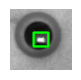

In [ ]:
sm_msk_img = read_img(sm_rect_msk)
contours = find_contours_binary(sm_msk_img)
h_offset = 30
w_offset = 30
for i in contours:

    x, y, w, h = cv2.boundingRect(i)
    pin_img = (sm_img[y-h_offset:y+h+h_offset, x-w_offset:x+w+w_offset])
    pin_msk = (sm_msk_img[y-h_offset:y+h+h_offset, x-w_offset:x+w+w_offset])
    overlay_img =overlay_mask_border_on_image_frm_img(pin_img, pin_msk)








In [ ]:
sm_msk = mask_path.ls()[0]
calculate_mask_stats(sm_msk)

{'filename': 'VFV4.9.0.3_2025031709435705_ID_00002046905819403042510_In_17_FRONT_Pass_image2.png',
 'num_objects': 23,
 'objects': [{'object_id': 0,
   'pixels': 370,
   'area': 332.5,
   'contour': array([[[1190,  887]],
   
          [[1190,  904]],
   
          [[1199,  904]],
   
          [[1200,  905]],
   
          [[1209,  905]],
   
          [[1209,  887]]], dtype=int32)},
  {'object_id': 1,
   'pixels': 379,
   'area': 341.5,
   'contour': array([[[924, 885]],
   
          [[923, 886]],
   
          [[923, 903]],
   
          [[942, 903]],
   
          [[942, 885]]], dtype=int32)},
  {'object_id': 2,
   'pixels': 350,
   'area': 313.5,
   'contour': array([[[754, 883]],
   
          [[754, 899]],
   
          [[763, 899]],
   
          [[764, 900]],
   
          [[773, 900]],
   
          [[773, 883]]], dtype=int32)},
  {'object_id': 3,
   'pixels': 358,
   'area': 322.0,
   'contour': array([[[664, 880]],
   
          [[663, 881]],
   
          [[663, 896]],
  

In [ ]:
#| export
CURRETNT_NB='/home/ai_sintercra/homes/hasan/projects/git_data/new_test/nbs'

In [ ]:
#| export
@call_parse
def main_(
    im_path:Param("Path to input images", str)='/path/to/images',
    msk_path:Param("Path to mask images", str)='/path/to/masks',
    h_offset:Param("Height offset for pin extraction", int)=30,
    w_offset:Param("Width offset for pin extraction", int)=30,
    min_area:Param("Minimum area threshold for pin detection", int)=100
    ):
    extract_and_save_pins_folder(
        im_path=im_path, 
        msk_path=msk_path, 
        h_offset=h_offset, 
        w_offset=w_offset, 
        min_area=min_area)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('40_preprocessing.zero_degree_solder_pin.mask_stats.ipynb')

ValueError: '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\nbs\\26_model_evaluation.new_model.ipynb' is not in the subpath of '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\new_test\\nbs'